In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('../data/creditcard.csv')

# Basic info
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())
print("\nClass Distribution:\n", df['Class'].value_counts())

Dataset Shape: (284807, 31)

Column Names:
 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 5 rows:
    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170  

In [2]:
# Check missing values and data info
print("Missing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
print("\nBasic Statistics:\n", df.describe())

Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Data Types:
 Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Basic Stati

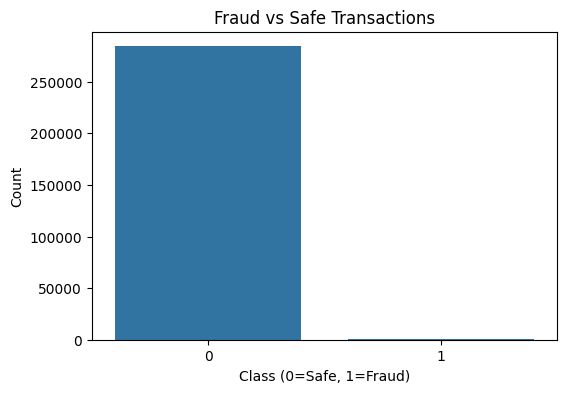

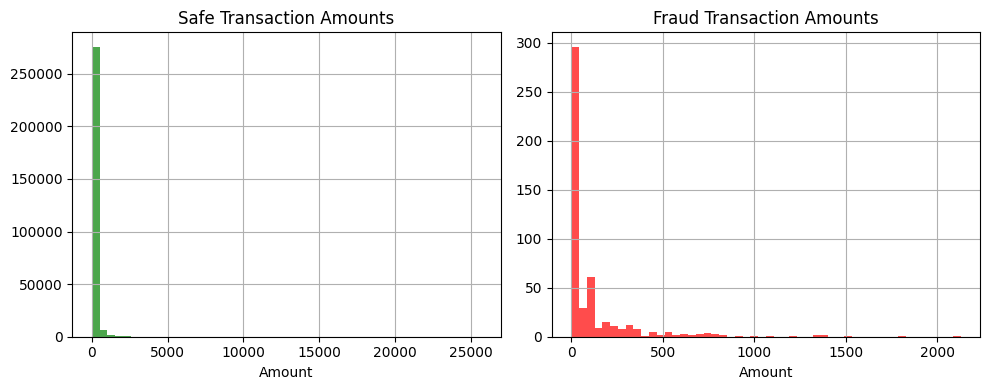

In [3]:
# Plot fraud vs safe
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Fraud vs Safe Transactions')
plt.xlabel('Class (0=Safe, 1=Fraud)')
plt.ylabel('Count')
plt.show()

# Plot amount distribution
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
df[df['Class']==0]['Amount'].hist(bins=50, color='green', alpha=0.7)
plt.title('Safe Transaction Amounts')
plt.xlabel('Amount')

plt.subplot(1,2,2)
df[df['Class']==1]['Amount'].hist(bins=50, color='red', alpha=0.7)
plt.title('Fraud Transaction Amounts')
plt.xlabel('Amount')
plt.tight_layout()
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler

# Scale Amount column
# V1-V28 already scaled by bank
# but Amount and Time are not scaled
scaler = StandardScaler()

df['Amount_Scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_Scaled'] = scaler.fit_transform(df[['Time']])

# Drop original Amount and Time
df = df.drop(['Amount', 'Time'], axis=1)

# Separate features and target
X = df.drop('Class', axis=1)  # all columns except Class
y = df['Class']                # only Class column

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
print("\nFeature columns:", X.columns.tolist())

Features Shape: (284807, 30)
Target Shape: (284807,)

Feature columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_Scaled', 'Time_Scaled']


In [5]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Step 1 - Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # same split every time
    stratify=y          # keep same fraud ratio
)

print("Before SMOTE:")
print("Training set size:", X_train.shape)
print("Fraud in training:", y_train.sum())
print("Safe in training:", (y_train==0).sum())

# Step 2 - Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("Training set size:", X_train_smote.shape)
print("Fraud in training:", y_train_smote.sum())
print("Safe in training:", (y_train_smote==0).sum())

Before SMOTE:
Training set size: (227845, 30)
Fraud in training: 394
Safe in training: 227451

After SMOTE:
Training set size: (454902, 30)
Fraud in training: 227451
Safe in training: 227451


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import time

# Dictionary to store results
results = {}

# Model 1 - Logistic Regression
print("Training Logistic Regression...")
start = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)
lr_time = time.time() - start
lr_pred = lr.predict(X_test)
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])
results['Logistic Regression'] = {
    'model': lr,
    'predictions': lr_pred,
    'auc': lr_auc,
    'time': lr_time
}
print(f"Done! Time: {lr_time:.2f}s | AUC: {lr_auc:.4f}")

# Model 2 - Random Forest
print("\nTraining Random Forest...")
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_smote, y_train_smote)
rf_time = time.time() - start
rf_pred = rf.predict(X_test)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
results['Random Forest'] = {
    'model': rf,
    'predictions': rf_pred,
    'auc': rf_auc,
    'time': rf_time
}
print(f"Done! Time: {rf_time:.2f}s | AUC: {rf_auc:.4f}")

# Model 3 - XGBoost
print("\nTraining XGBoost...")
start = time.time()
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(X_train_smote, y_train_smote)
xgb_time = time.time() - start
xgb_pred = xgb.predict(X_test)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])
results['XGBoost'] = {
    'model': xgb,
    'predictions': xgb_pred,
    'auc': xgb_auc,
    'time': xgb_time
}
print(f"Done! Time: {xgb_time:.2f}s | AUC: {xgb_auc:.4f}")

Training Logistic Regression...
Done! Time: 2.69s | AUC: 0.9698

Training Random Forest...
Done! Time: 662.73s | AUC: 0.9688

Training XGBoost...
Done! Time: 14.09s | AUC: 0.9792



Model: Logistic Regression
AUC Score: 0.9698
Training Time: 2.69s

Classification Report:
              precision    recall  f1-score   support

        Safe       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


Model: Random Forest
AUC Score: 0.9688
Training Time: 662.73s

Classification Report:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     56864
       Fraud       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962


Model: XGBoost
AUC Score: 0.9792
Training Time: 14.09s

Classification Report:
              precision    recall  f1-score   support

        Safe       1.00      1.00

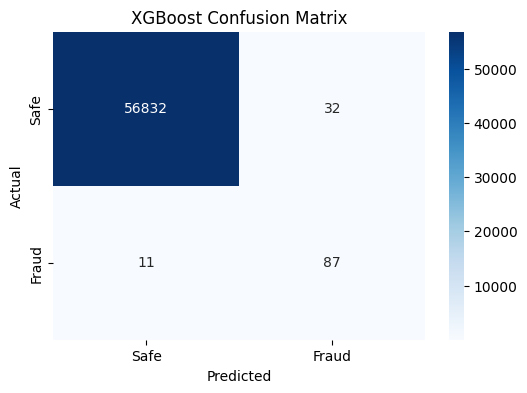

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Compare all models
for name, result in results.items():
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"AUC Score: {result['auc']:.4f}")
    print(f"Training Time: {result['time']:.2f}s")
    print(f"\nClassification Report:")
    print(classification_report(y_test, result['predictions'],
          target_names=['Safe', 'Fraud']))

# Plot confusion matrix for XGBoost
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe', 'Fraud'],
            yticklabels=['Safe', 'Fraud'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [8]:
from sklearn.model_selection import GridSearchCV

print("Tuning XGBoost...")

# Try different parameters
params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
}

grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    params,
    cv=3,
    scoring='recall',  # optimize for catching fraud
    n_jobs=-1
)

grid.fit(X_train_smote, y_train_smote)

print("Best Parameters:", grid.best_params_)
print("Best Recall Score:", grid.best_score_)

# Train final model with best params
best_xgb = grid.best_estimator_
best_pred = best_xgb.predict(X_test)
best_auc = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1])

print("\nFinal Model Results:")
print(classification_report(y_test, best_pred,
      target_names=['Safe', 'Fraud']))
print(f"AUC: {best_auc:.4f}")

Tuning XGBoost...
Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Best Recall Score: 1.0

Final Model Results:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     56864
       Fraud       0.71      0.87      0.78        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962

AUC: 0.9804


Calculating SHAP values...


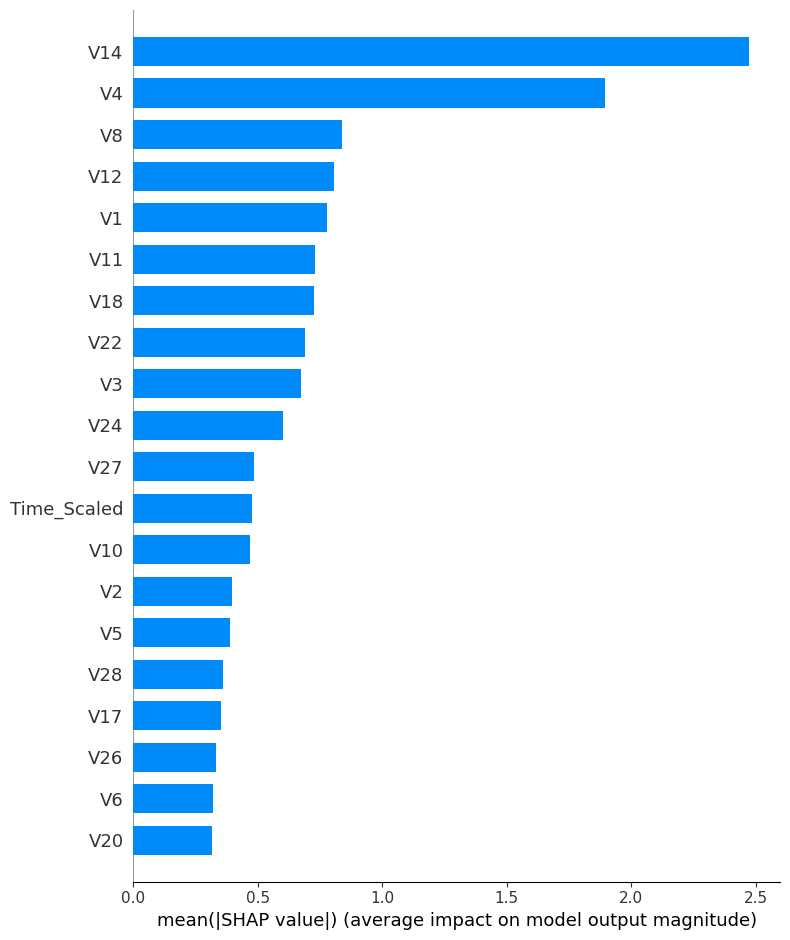

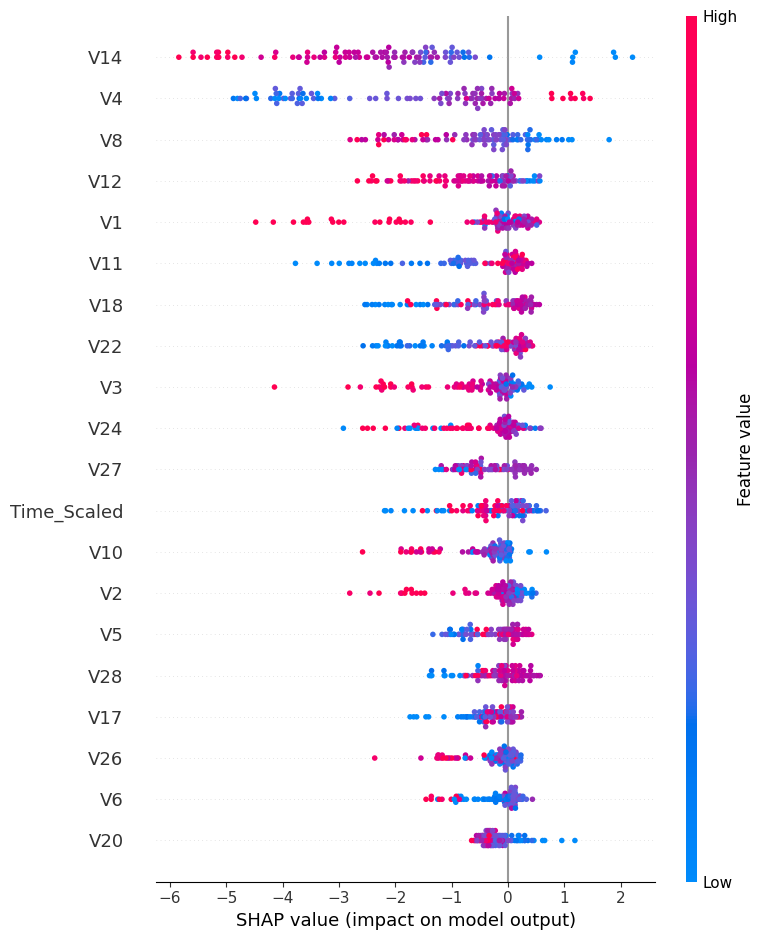

SHAP Done!


In [9]:
import shap

print("Calculating SHAP values...")

# Use previous XGBoost (better model)
explainer = shap.TreeExplainer(xgb)

# Take small sample for speed
X_test_sample = X_test.iloc[:100]

shap_values = explainer.shap_values(X_test_sample)

# Plot 1 - Feature Importance
plt.figure()
shap.summary_plot(shap_values, X_test_sample, 
                  plot_type="bar",
                  show=True)

# Plot 2 - Detailed SHAP
shap.summary_plot(shap_values, X_test_sample,
                  show=True)

print("SHAP Done!")

In [10]:
import pickle
import json

# Save XGBoost model
pickle.dump(xgb, open('../models/fraud_model.pkl', 'wb'))

# Save SHAP explainer
pickle.dump(explainer, open('../models/shap_explainer.pkl', 'wb'))

# Save feature names
feature_names = X.columns.tolist()
with open('../models/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("✅ Model saved!")
print("✅ SHAP explainer saved!")
print("✅ Feature names saved!")

# Verify files saved
import os
files = os.listdir('../models/')
print("\nSaved files:", files)

✅ Model saved!
✅ SHAP explainer saved!
✅ Feature names saved!

Saved files: ['feature_names.json', 'fraud_model.pkl', 'shap_explainer.pkl']


In [11]:
# Test saved model works correctly
import pickle
import json
import numpy as np

# Load saved model
model = pickle.load(open('../models/fraud_model.pkl', 'rb'))
explainer = pickle.load(open('../models/shap_explainer.pkl', 'rb'))
feature_names = json.load(open('../models/feature_names.json', 'r'))

# Create fake transaction to test
fake_transaction = np.zeros(30)  # 30 features
fake_transaction[0] = -5.0       # Low V1 (suspicious)
fake_transaction[13] = -10.0     # Low V14 (most important!)
fake_transaction[28] = 2.5       # High amount

# Predict
prediction = model.predict([fake_transaction])[0]
probability = model.predict_proba([fake_transaction])[0][1]
risk_score = round(probability * 100)

# SHAP explanation
shap_vals = explainer.shap_values([fake_transaction])[0]
top_features = sorted(zip(feature_names, shap_vals), 
                      key=lambda x: abs(x[1]), 
                      reverse=True)[:3]

print("Test Transaction Result:")
print(f"Risk Score: {risk_score}/100")
print(f"Prediction: {'🚨 FRAUD' if prediction == 1 else '✅ SAFE'}")
print(f"\nTop Reasons:")
for feature, value in top_features:
    impact = "increases fraud risk" if value > 0 else "decreases fraud risk"
    print(f"  {feature}: {impact} ({value:.3f})")

Test Transaction Result:
Risk Score: 100/100
Prediction: 🚨 FRAUD

Top Reasons:
  V14: increases fraud risk (5.748)
  V12: decreases fraud risk (-0.942)
  V10: decreases fraud risk (-0.914)
